# Streaming Martingale Monitoring

This notebook monitors conformal p-values on a credit-card fraud stream. It compares product martingales, the restarted mixture e-process, CUSUM, and Shiryaev-Roberts evidence statistics.


## Import

Load the fraud benchmark, conformal detector, martingales, and plotting tools.


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from oddball import Dataset, load
from sklearn.ensemble import IsolationForest

from nonconform import ConformalDetector, Split
from nonconform.martingales import (
    AlarmConfig,
    PowerMartingale,
    SimpleJumperMartingale,
    SimpleMixtureMartingale,
)

## Setup

Hold out 2,000 normal transactions for detector fitting and calibration. The stream starts with normal transactions only, then gradually samples from the fraud pool.


In [2]:
rng = np.random.default_rng(42)
x_train, x_test, y_test = load(Dataset.FRAUD, setup=True, seed=42)
x_train = np.asarray(x_train)
x_test = np.asarray(x_test)
y_test = np.asarray(y_test)

n_reference = 2_000
warmup_steps = 1_000
horizon = 3_000
alpha = 0.01

x_reference = x_train[:n_reference]
x_normal_pool = np.vstack([x_train[n_reference:], x_test[y_test == 0]])
x_anomaly_pool = x_test[y_test != 0]

detector = ConformalDetector(
    detector=IsolationForest(random_state=42),
    strategy=Split(n_calib=0.25),
    score_polarity="auto",
    seed=42,
)
detector.fit(x_reference)

alarms = AlarmConfig(
    ville_threshold=1 / alpha,
    restarted_ville_threshold=1 / alpha,
    cusum_threshold=100.0,  # comparison threshold, not a Ville threshold
    shiryaev_roberts_threshold=100.0,
)
martingales = {
    "power": PowerMartingale(epsilon=0.5, alarm_config=alarms),
    "mixture": SimpleMixtureMartingale(
        epsilons=[0.25, 0.5, 0.75, 1.0],
        alarm_config=alarms,
    ),
    "jumper": SimpleJumperMartingale(jump=0.01, alarm_config=alarms),
}

print(
    f"reference={x_reference.shape}, normal_pool={x_normal_pool.shape}, "
    f"anomaly_pool={x_anomaly_pool.shape}, horizon={horizon}"
)

reference=(2000, 29), normal_pool=(141057, 29), anomaly_pool=(100, 29), horizon=3000


## Stream Processing

The stream uses normal points for the first 1,000 steps. Afterward the target fraud rate ramps linearly to 100% by the final step. Fraud examples are sampled with replacement.


In [3]:
def fraud_stream(
    normal_pool: np.ndarray,
    anomaly_pool: np.ndarray,
    *,
    warmup: int,
    horizon: int,
):
    """Yield a warmup-normal stream followed by a gradual fraud-rate ramp."""
    normal_order = rng.permutation(len(normal_pool))
    normal_i = 0

    for step in range(1, horizon + 1):
        if step <= warmup:
            target_rate = 0.0
        else:
            ramp = min(1.0, (step - warmup) / (horizon - warmup))
            target_rate = ramp

        take_anomaly = rng.random() < target_rate
        if take_anomaly:
            idx = rng.integers(len(anomaly_pool))
            yield step, anomaly_pool[idx], 1, target_rate
        else:
            idx = normal_order[normal_i % len(normal_order)]
            normal_i += 1
            yield step, normal_pool[idx], 0, target_rate


records: list[dict[str, float | int | tuple[str, ...]]] = []
stream_features: list[np.ndarray] = []
first_alarm_step: dict[tuple[str, str], int | None] = {
    (name, alarm): None
    for name in martingales
    for alarm in ("ville", "restarted_ville", "cusum", "shiryaev_roberts")
}

for step, x_t, y_t, target_rate in fraud_stream(
    x_normal_pool,
    x_anomaly_pool,
    warmup=warmup_steps,
    horizon=horizon,
):
    x_t_row = x_t.reshape(1, -1)
    score_t = float(detector.score_samples(x_t_row)[0])
    p_t = float(detector.compute_p_values(x_t_row)[0])

    row: dict[str, float | int | tuple[str, ...]] = {
        "step": step,
        "is_anomaly": y_t,
        "target_anomaly_rate": target_rate,
        "anomaly_score": score_t,
        "p_value": p_t,
    }

    for name, martingale in martingales.items():
        state = martingale.update(p_t)
        row[f"{name}_M"] = state.martingale
        row[f"{name}_log10_M"] = state.log_martingale / np.log(10.0)
        row[f"{name}_restarted_M"] = state.restarted_martingale
        row[f"{name}_log10_restarted_M"] = state.log_restarted_martingale / np.log(10.0)
        row[f"{name}_CUSUM"] = state.cusum
        row[f"{name}_SR"] = state.shiryaev_roberts
        row[f"{name}_alarms"] = state.triggered_alarms

        for alarm in state.triggered_alarms:
            key = (name, alarm)
            if first_alarm_step[key] is None:
                first_alarm_step[key] = step

    records.append(row)
    stream_features.append(x_t)

df = pd.DataFrame.from_records(records)
x_stream = np.vstack(stream_features)
df.head()

,step,is_anomaly,target_anomaly_rate,anomaly_score,p_value,power_M,power_log10_M,power_restarted_M,power_log10_restarted_M,power_CUSUM,...,mixture_CUSUM,mixture_SR,mixture_alarms,jumper_M,jumper_log10_M,jumper_restarted_M,jumper_log10_restarted_M,jumper_CUSUM,jumper_SR,jumper_alarms
0,1,0,0.0,-0.399410,0.598802,0.646142,-0.189672,0.823071,-0.084563,0.646142,...,0.716499,0.716499,(),1.000000,-9.643275e-17,1.000000,-4.821637e-17,1.000000,1.000000,()
1,2,0,0.0,-0.381336,0.383234,0.521875,-0.282434,0.728884,-0.137342,0.807678,...,0.880353,1.511126,(),0.992386,-3.319499e-03,0.994924,-2.210178e-03,0.992386,1.984771,()
2,3,0,0.0,-0.407714,0.710579,0.309550,-0.509270,0.534050,-0.272418,0.593149,...,0.806284,2.024681,(),0.989752,-4.473741e-03,0.992947,-3.074098e-03,0.997346,2.976849,()
3,4,0,0.0,-0.359611,0.191617,0.353577,-0.451516,0.581561,-0.235405,1.142229,...,1.061141,3.209613,(),0.951199,-2.172877e-02,0.962060,-1.679803e-02,0.961048,3.821942,()
4,5,0,0.0,-0.425219,0.918164,0.184499,-0.734006,0.383162,-0.416618,0.596023,...,0.872580,3.461579,(),0.919144,-3.661644e-02,0.935255,-2.906975e-02,0.966301,4.659446,()


## First Alarm Steps

Summarize the first alarm step for each method and alarm configuration. Product and restarted Ville alarms have anytime false-alarm probability control; CUSUM and SR are displayed as comparison thresholds.


In [4]:
summary_rows = []
for name in martingales:
    summary_rows.append(
        {
            "martingale": name,
            "first_ville": first_alarm_step[name, "ville"],
            "first_restarted_ville": first_alarm_step[
                name,
                "restarted_ville",
            ],
            "first_cusum_comparison": first_alarm_step[name, "cusum"],
            "first_sr_comparison": first_alarm_step[name, "shiryaev_roberts"],
        }
    )

summary = pd.DataFrame(summary_rows)
summary

,martingale,first_ville,first_restarted_ville,first_cusum_comparison,first_sr_comparison
0,power,2075,1409,955,518
1,mixture,1597,1594,1593,125
2,jumper,1439,1438,1183,95


## Evidence Visualization

The final panel compares the product martingale with the restarted mixture e-process. The restarted line is the Ville-valid CUSUM-like route.


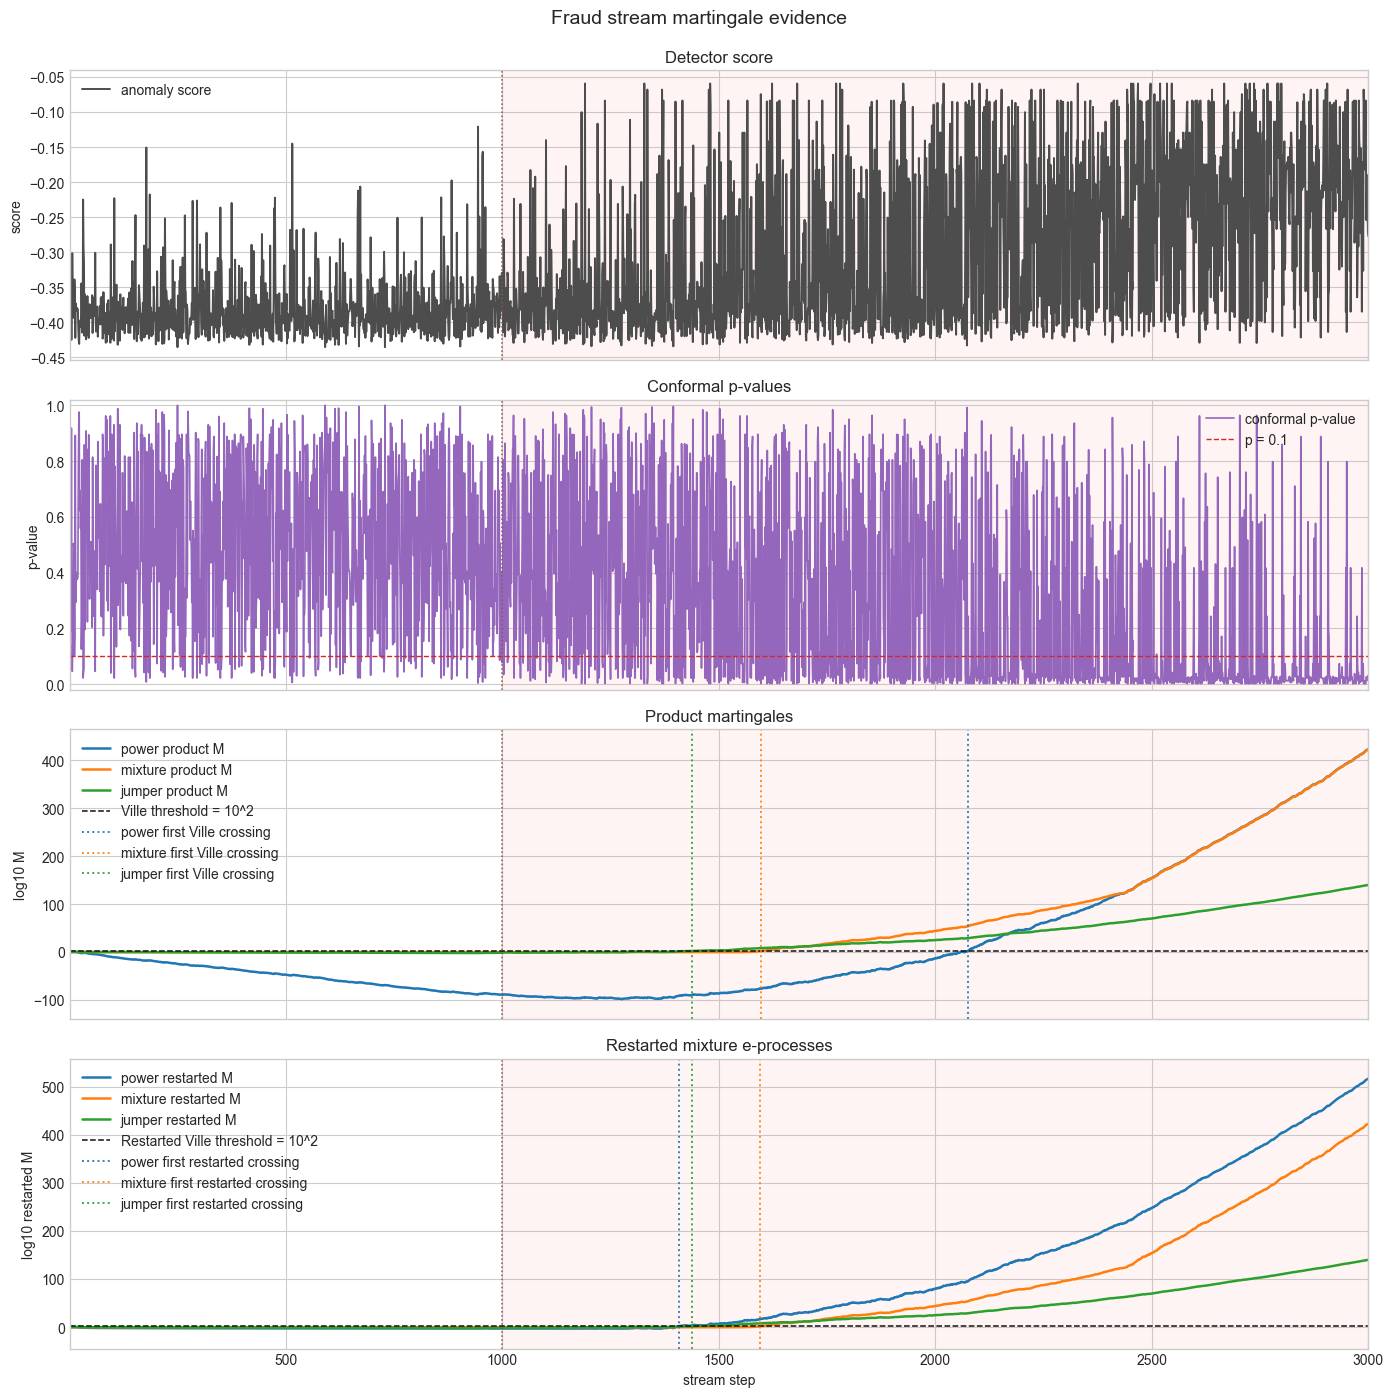

In [5]:
plt.style.use("seaborn-v0_8-whitegrid")

colors = {
    "power": "#1f77b4",
    "mixture": "#ff7f0e",
    "jumper": "#2ca02c",
}


def set_linear_margin(ax, values, threshold):
    """Set padded linear limits for log10 evidence trajectories."""
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return
    lower = min(float(np.min(finite)), threshold)
    upper = max(float(np.max(finite)), threshold)
    pad = max((upper - lower) * 0.08, 1.0)
    ax.set_ylim(lower - pad, upper + pad)


def add_first_crossing_lines(ax, alarm_name, label_suffix):
    """Add one vertical threshold-crossing line per martingale method."""
    for name, color in colors.items():
        alarm_step = first_alarm_step[name, alarm_name]
        if alarm_step is None:
            continue
        ax.axvline(
            alarm_step,
            color=color,
            ls=":",
            lw=1.4,
            alpha=0.9,
            label=f"{name} first {label_suffix}",
        )


fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

axes[0].plot(
    df["step"],
    df["anomaly_score"],
    color="#4d4d4d",
    lw=1.4,
    label="anomaly score",
)
axes[0].set_title("Detector score")
axes[0].set_ylabel("score")
axes[0].legend(loc="upper left")

axes[1].plot(
    df["step"],
    df["p_value"],
    color="#9467bd",
    lw=1.2,
    label="conformal p-value",
)
axes[1].axhline(0.1, color="#d62728", ls="--", lw=1.0, label="p = 0.1")
axes[1].set_title("Conformal p-values")
axes[1].set_ylabel("p-value")
axes[1].set_ylim(-0.02, 1.02)
axes[1].legend(loc="upper right")

ville_log10 = np.log10(alarms.ville_threshold)
for name in ["power", "mixture", "jumper"]:
    axes[2].plot(
        df["step"],
        df[f"{name}_log10_M"],
        color=colors[name],
        lw=1.8,
        label=f"{name} product M",
    )
axes[2].axhline(
    ville_log10,
    color="#111111",
    ls="--",
    lw=1.1,
    label=f"Ville threshold = 10^{ville_log10:g}",
)
set_linear_margin(
    axes[2],
    np.concatenate([df[f"{name}_log10_M"].to_numpy() for name in colors]),
    ville_log10,
)
add_first_crossing_lines(axes[2], "ville", "Ville crossing")
axes[2].set_title("Product martingales")
axes[2].set_ylabel("log10 M")
axes[2].legend(loc="upper left")

restarted_ville_log10 = np.log10(alarms.restarted_ville_threshold)
for name in ["power", "mixture", "jumper"]:
    axes[3].plot(
        df["step"],
        df[f"{name}_log10_restarted_M"],
        color=colors[name],
        lw=1.8,
        label=f"{name} restarted M",
    )
axes[3].axhline(
    restarted_ville_log10,
    color="#111111",
    ls="--",
    lw=1.1,
    label=f"Restarted Ville threshold = 10^{restarted_ville_log10:g}",
)
set_linear_margin(
    axes[3],
    np.concatenate([df[f"{name}_log10_restarted_M"].to_numpy() for name in colors]),
    restarted_ville_log10,
)
add_first_crossing_lines(axes[3], "restarted_ville", "restarted crossing")
axes[3].set_title("Restarted mixture e-processes")
axes[3].set_ylabel("log10 restarted M")
axes[3].set_xlabel("stream step")
axes[3].legend(loc="upper left")

for ax in axes:
    ax.axvline(warmup_steps, color="#8c564b", ls=":", lw=1.1)
    ax.axvspan(warmup_steps, horizon, color="#ff9896", alpha=0.10)
    ax.set_xlim(1, horizon)

fig.suptitle("Fraud stream martingale evidence", fontsize=14, y=0.995)
fig.tight_layout()
plt.show()